## Question 1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
def intensity_transform(im, breakpoints):
    """
    Applying a piecewise-linear intensity transformation defined by breakpoints.
    """
    bp = np.array(breakpoints, dtype=np.float64)
    lut = np.zeros(256, dtype=np.float64)
    levels = np.arange(256)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        if i == len(bp) - 2:
            mask = (levels >= x0) & (levels <= x1)
        else:
            mask = (levels >= x0) & (levels < x1)
        if x1 == x0:
            lut[mask] = y1
        else:
            lut[mask] = y0 + (y1 - y0) * (levels[mask] - x0) / (x1 - x0)

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut), lut


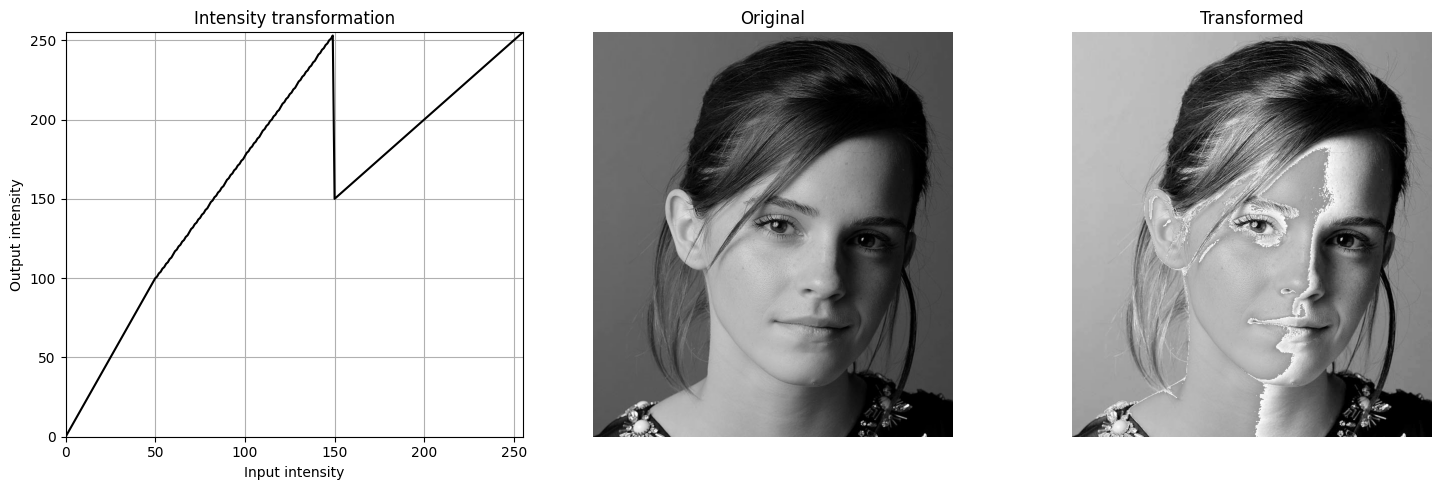

In [3]:
img = cv2.imread('images/emma.jpg', cv2.IMREAD_GRAYSCALE)

breakpoints = [[0, 0], [50, 100], [150, 255], [150, 150], [255, 255]]

transformed, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 2

### (a) Accentuating white matter

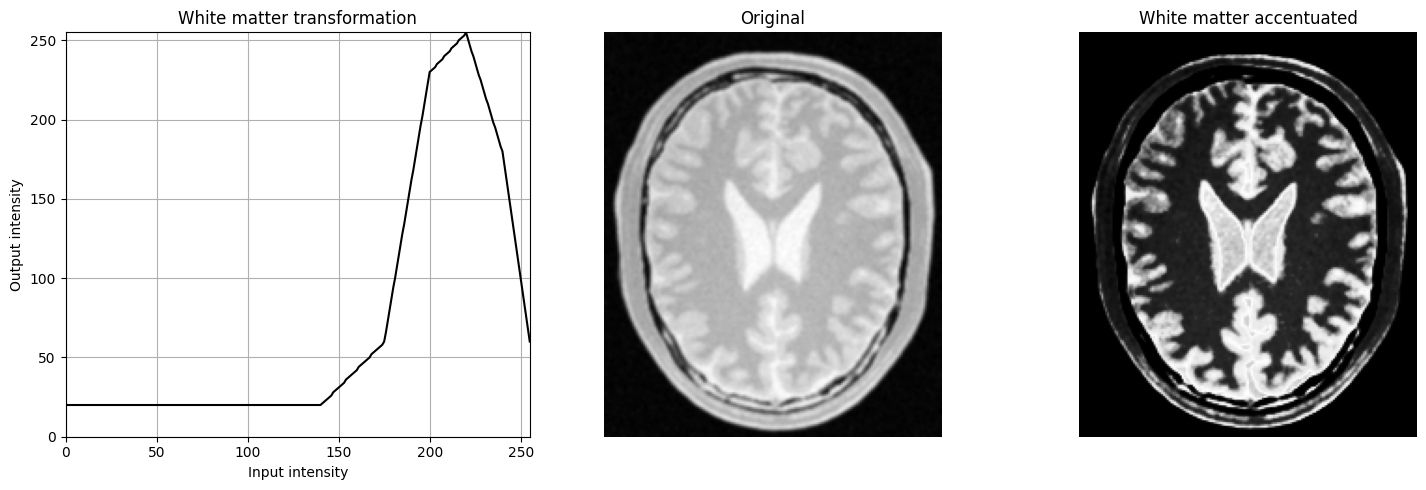

In [4]:
img2 = cv2.imread('images/brain_proton_density.jpeg', cv2.IMREAD_GRAYSCALE)
# A light blur first suppresses JPEG blockiness so the stretch below doesn't
# turn compression artifacts into visible noise.
img2 = cv2.GaussianBlur(img2, (3, 3), 0)

# White matter sits roughly in the 200-220 intensity band in this image.
# So we need a ramp that band up towards 255 while suppressing everything else.
white_bp = [[0, 20], [140, 20], [175, 60], [200, 230], [220, 255], [240, 180], [255, 60]]

# Reusing the same intensity_transform function from Q1
white_out, white_lut = intensity_transform(img2, white_bp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), white_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray')
axes[2].set_title('White matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Accentuating gray matter

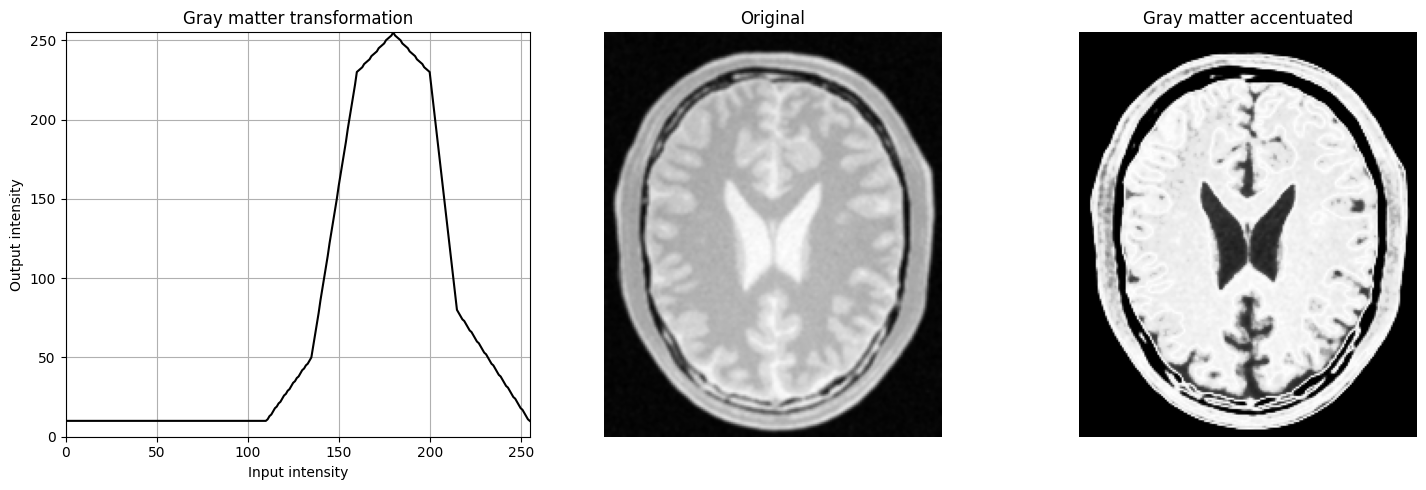

In [5]:
# Gray matter sits in a lower band (160-180), so we need to increase that
# while suppressing background, white matter, and the skull/scalp.
gray_bp = [[0, 10], [110, 10], [135, 50], [160, 230], [180, 255], [200, 230], [215, 80], [255, 10]]

gray_out, gray_lut = intensity_transform(img2, gray_bp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), gray_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Gray matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Question 3

### (a) Gamma correction on the L plane in L*a*b* space

gamma = 0.5

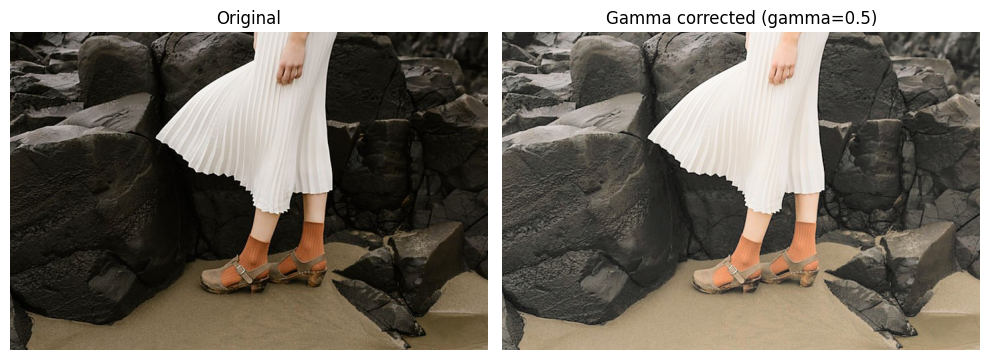

In [6]:
img3 = cv2.imread('images/gamma_correction.jpeg')
lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Most of the image (the rocks) is dark, so gamma < 1 lifts the shadows
gamma = 0.5
L_corrected = (255.0 * (L / 255.0) ** gamma).clip(0, 255).astype(np.uint8)

lab_corrected = cv2.merge([L_corrected, a, b])
img3_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img3_corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (gamma={gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### (b) Histograms before and after correction

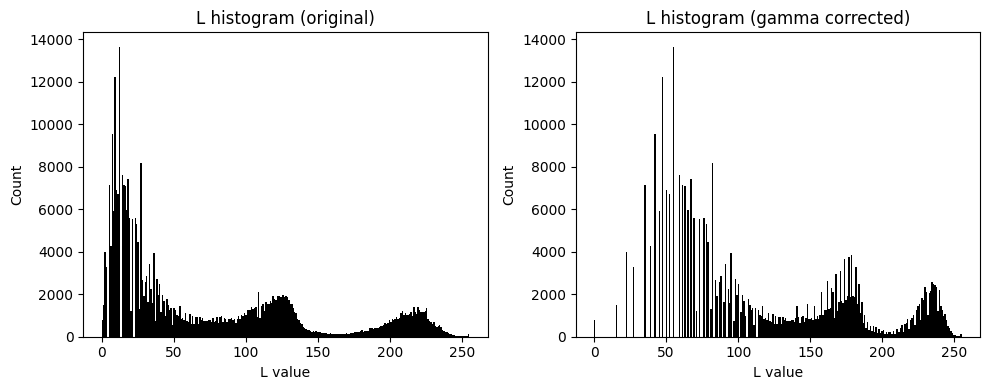

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(L.flatten(), bins=256, range=(0, 255), color='k')
axes[0].set_title('L histogram (original)')
axes[0].set_xlabel('L value')
axes[0].set_ylabel('Count')

axes[1].hist(L_corrected.flatten(), bins=256, range=(0, 255), color='k')
axes[1].set_title('L histogram (gamma corrected)')
axes[1].set_xlabel('L value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Question 4

### (a) Split into hue, saturation, and value planes

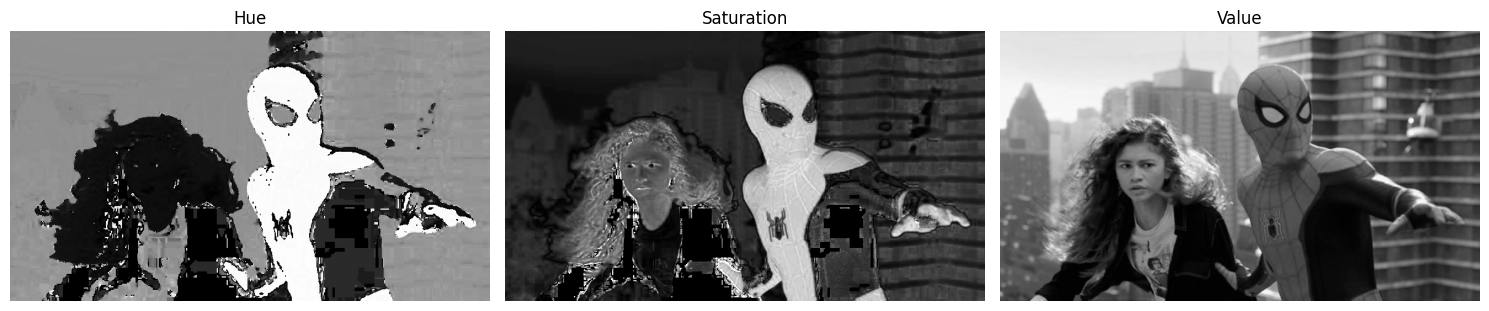

In [8]:
img4 = cv2.imread('images/vibrance.jpeg')
hsv = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(H, cmap='gray')
axes[0].set_title('Hue')
axes[0].axis('off')

axes[1].imshow(S, cmap='gray')
axes[1].set_title('Saturation')
axes[1].axis('off')

axes[2].imshow(V, cmap='gray')
axes[2].set_title('Value')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Apply the vibrance transformation to the saturation plane

In [9]:
sigma = 70
a = 0.8  # chosen by trying a few values and picking the most visually pleasing

x = np.arange(256).astype(np.float64)
vibrance_curve = np.minimum(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 255)
vibrance_lut = vibrance_curve.astype(np.uint8)

S_boosted = cv2.LUT(S, vibrance_lut)


### (c) Choosing the value for 'a'
Chose a = 0.8 (It was the most visually pleasing value)

### (d) Recombine the planes

In [10]:
hsv_boosted = cv2.merge([H, S_boosted, V])
img4_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)


### (e) Original, vibrance-enhanced image, and the transformation

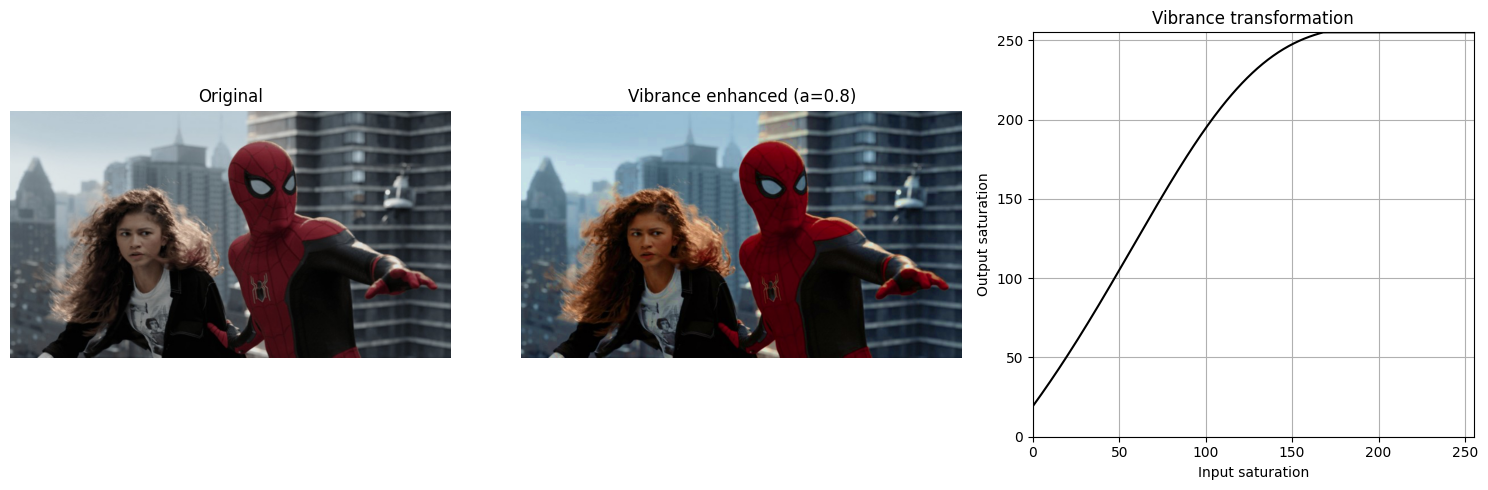

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img4_boosted, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a={a})')
axes[1].axis('off')

axes[2].plot(x, vibrance_curve, color='k')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Vibrance transformation')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## Question 5

In [12]:
def histogram_equalization(im):
    """Equalize the histogram of a grayscale image using its cumulative
    distribution function, mapped to the full 0-255 range."""
    hist = np.bincount(im.flatten(), minlength=256)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    lut = (cdf - cdf_min) / (cdf[-1] - cdf_min) * 255
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[im]


[ WARN:0@5.443] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


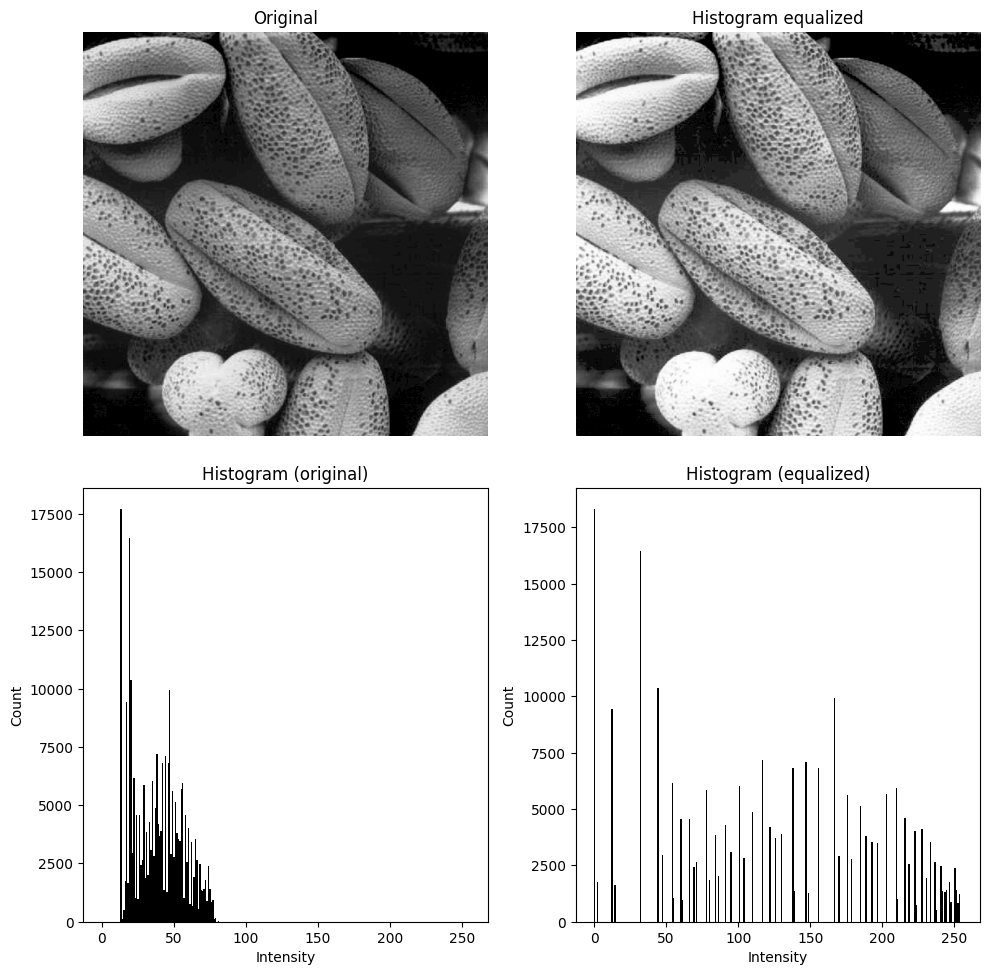

In [13]:
img5 = cv2.imread('images/shells.tif', cv2.IMREAD_GRAYSCALE)
img5_eq = histogram_equalization(img5)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img5, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(img5_eq, cmap='gray')
axes[0, 1].set_title('Histogram equalized')
axes[0, 1].axis('off')

axes[1, 0].hist(img5.flatten(), bins=256, range=(0, 255), color='k')
axes[1, 0].set_title('Histogram (original)')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(img5_eq.flatten(), bins=256, range=(0, 255), color='k')
axes[1, 1].set_title('Histogram (equalized)')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Question 6

### (a) Split into hue, saturation, and value planes

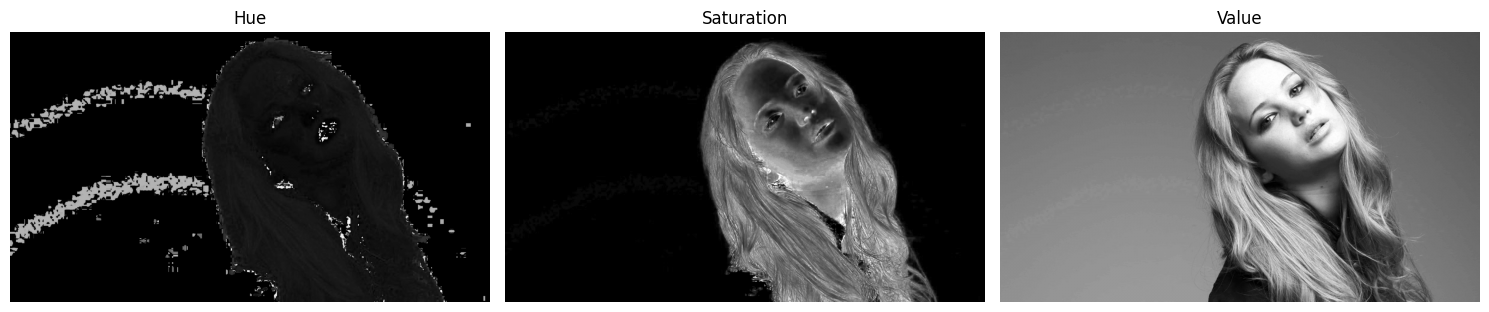

In [14]:
img6 = cv2.imread('images/foreground_segmentation.jpeg')
hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
H6, S6, V6 = cv2.split(hsv6)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(H6, cmap='gray')
axes[0].set_title('Hue')
axes[0].axis('off')

axes[1].imshow(S6, cmap='gray')
axes[1].set_title('Saturation')
axes[1].axis('off')

axes[2].imshow(V6, cmap='gray')
axes[2].set_title('Value')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Threshold to extract the foreground mask

Neither the saturation plane nor the value plane alone cleanly separates the person from the background (the background has a brightness gradient that overlaps the skin/hair tones), so both are thresholded and combined.

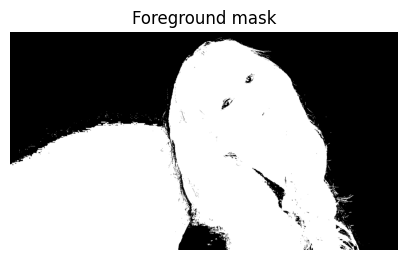

In [15]:
# Otsu's threshold on saturation catches the hair and clothing, and Otsu's
# threshold on value catches the brighter side of the face, combine both
mask_s = cv2.threshold(S6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
mask_v = cv2.threshold(V6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
mask = cv2.bitwise_or(mask_s, mask_v)

plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='gray')
plt.title('Foreground mask')
plt.axis('off')
plt.show()


### (c) Extract the foreground and compute its histogram

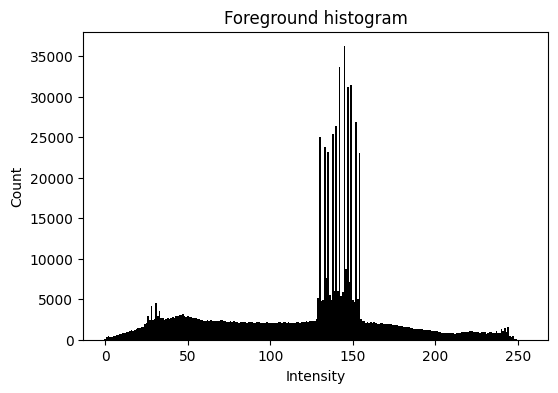

In [16]:
gray6 = cv2.cvtColor(img6, cv2.COLOR_BGR2GRAY)
foreground = cv2.bitwise_and(gray6, gray6, mask=mask)

# Histogram computed only over the masked in (foreground) pixels
hist = cv2.calcHist([gray6], [0], mask, [256], [0, 256]).flatten()

plt.figure(figsize=(6, 4))
plt.bar(np.arange(256), hist, color='k', width=1)
plt.title('Foreground histogram')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()


### (d) Cumulative sum of the foreground histogram

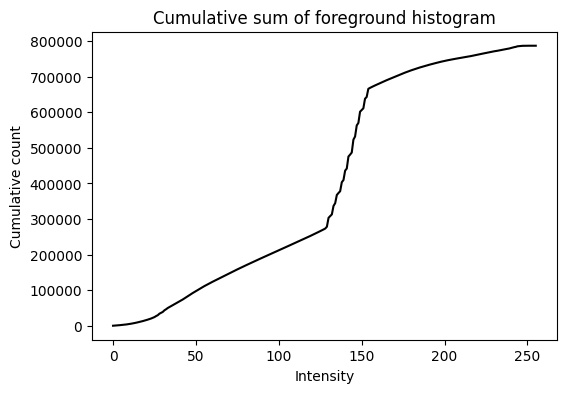

In [17]:
cdf = np.cumsum(hist)

plt.figure(figsize=(6, 4))
plt.plot(cdf, color='k')
plt.title('Cumulative sum of foreground histogram')
plt.xlabel('Intensity')
plt.ylabel('Cumulative count')
plt.show()


### (e) Histogram-equalize the foreground

In [18]:
cdf_min = cdf[cdf > 0].min()
lut = np.clip((cdf - cdf_min) / (cdf[-1] - cdf_min) * 255, 0, 255).astype(np.uint8)

# Reusing the same equalization formula as Q5, but the LUT is built only from the foreground's own histogram
foreground_eq_full = lut[gray6]
foreground_eq = cv2.bitwise_and(foreground_eq_full, foreground_eq_full, mask=mask)


### (f) Extract the background and add it to the equalized foreground

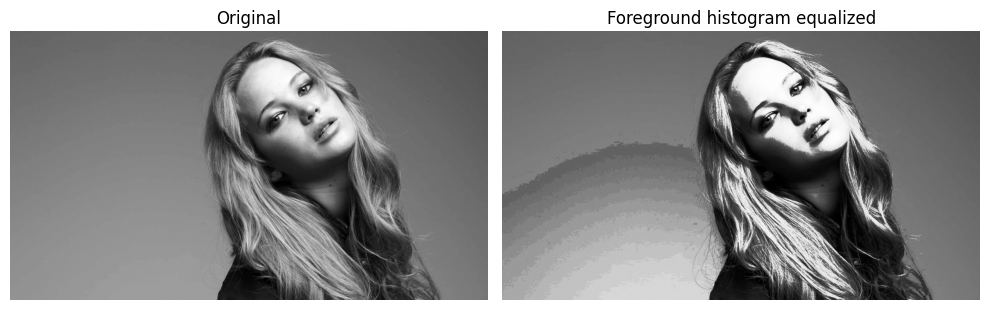

In [19]:
background = cv2.bitwise_and(gray6, gray6, mask=cv2.bitwise_not(mask))
result6 = cv2.add(foreground_eq, background)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray6, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(result6, cmap='gray')
axes[1].set_title('Foreground histogram equalized')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Question 7

### (a) Sobel filtering using filter2D

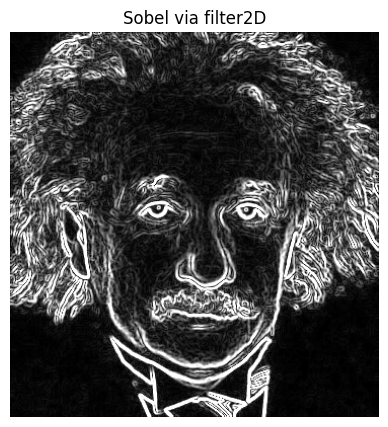

In [20]:
img7 = cv2.imread('images/sobel.jpeg', cv2.IMREAD_GRAYSCALE).astype(np.float64)

Gx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64)
Gy = Gx.T

sx_a = cv2.filter2D(img7, -1, Gx)
sy_a = cv2.filter2D(img7, -1, Gy)
mag_a = np.clip(np.sqrt(sx_a ** 2 + sy_a ** 2), 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(mag_a, cmap='gray')
plt.title('Sobel via filter2D')
plt.axis('off')
plt.show()


### (b) Writing our own Sobel filtering code

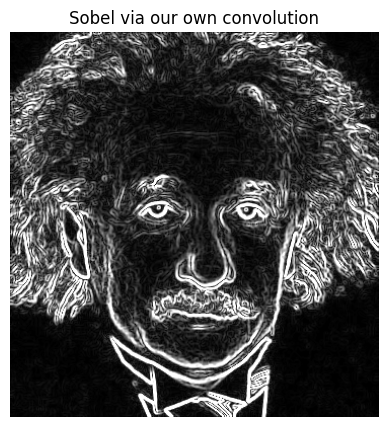

Max difference from filter2D result: 0


In [21]:
def convolve2d(im, kernel):
    """Straightforward 2D convolution/correlation with reflect padding."""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    out = np.zeros_like(im)
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i + im.shape[0], j:j + im.shape[1]]
    return out

sx_b = convolve2d(img7, Gx)
sy_b = convolve2d(img7, Gy)
mag_b = np.clip(np.sqrt(sx_b ** 2 + sy_b ** 2), 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(mag_b, cmap='gray')
plt.title('Sobel via our own convolution')
plt.axis('off')
plt.show()

print('Max difference from filter2D result:', np.abs(mag_a.astype(int) - mag_b.astype(int)).max())


### (c) Sobel filtering using the separable property

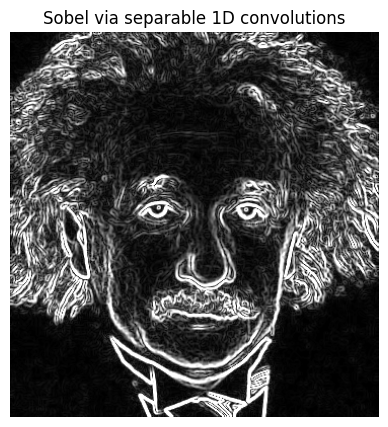

Max difference from part (b) result: 0


In [22]:
def convolve1d(im, kernel_1d, axis):
    """1D convolution along one axis with reflect padding."""
    k = len(kernel_1d)
    pad = k // 2
    out = np.zeros_like(im)
    if axis == 0:
        padded = np.pad(im, ((pad, pad), (0, 0)), mode='reflect')
        for i in range(k):
            out += kernel_1d[i] * padded[i:i + im.shape[0], :]
    else:
        padded = np.pad(im, ((0, 0), (pad, pad)), mode='reflect')
        for i in range(k):
            out += kernel_1d[i] * padded[:, i:i + im.shape[1]]
    return out

v = np.array([1, 2, 1], dtype=np.float64)   # smoothing kernel
h = np.array([1, 0, -1], dtype=np.float64)  # differencing kernel

# Gx = smooth vertically, then difference horizontally (and vice versa for Gy)
sx_c = convolve1d(convolve1d(img7, v, axis=0), h, axis=1)
sy_c = convolve1d(convolve1d(img7, h, axis=0), v, axis=1)
mag_c = np.clip(np.sqrt(sx_c ** 2 + sy_c ** 2), 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(mag_c, cmap='gray')
plt.title('Sobel via separable 1D convolutions')
plt.axis('off')
plt.show()

print('Max difference from part (b) result:', np.abs(mag_b.astype(int) - mag_c.astype(int)).max())


## Question 8

### Zoom function supporting nearest-neighbor and bilinear interpolation

In [23]:
def zoom_image(img, s, method='bilinear'):
    """Zoom an image by factor s in (0, 10] using nearest-neighbor or
    bilinear interpolation."""
    h, w = img.shape[:2]
    new_h, new_w = max(1, round(h * s)), max(1, round(w * s))

    # Map output pixel centers back to input coordinate space
    ys = (np.arange(new_h) + 0.5) / s - 0.5
    xs = (np.arange(new_w) + 0.5) / s - 0.5

    if method == 'nearest':
        ys_n = np.clip(np.round(ys), 0, h - 1).astype(int)
        xs_n = np.clip(np.round(xs), 0, w - 1).astype(int)
        return img[ys_n][:, xs_n]

    elif method == 'bilinear':
        ys_c = np.clip(ys, 0, h - 1)
        xs_c = np.clip(xs, 0, w - 1)
        y0 = np.floor(ys_c).astype(int)
        x0 = np.floor(xs_c).astype(int)
        y1 = np.clip(y0 + 1, 0, h - 1)
        x1 = np.clip(x0 + 1, 0, w - 1)
        wy = (ys_c - y0).reshape(-1, 1)
        wx = (xs_c - x0).reshape(1, -1)

        img_f = img.astype(np.float64)
        if img.ndim == 2:
            Ia, Ib = img_f[y0][:, x0], img_f[y0][:, x1]
            Ic, Id = img_f[y1][:, x0], img_f[y1][:, x1]
            top = Ia * (1 - wx) + Ib * wx
            bot = Ic * (1 - wx) + Id * wx
            out = top * (1 - wy) + bot * wy
        else:
            wy3, wx3 = wy[:, :, None], wx[:, :, None]
            Ia, Ib = img_f[y0][:, x0], img_f[y0][:, x1]
            Ic, Id = img_f[y1][:, x0], img_f[y1][:, x1]
            top = Ia * (1 - wx3) + Ib * wx3
            bot = Ic * (1 - wx3) + Id * wx3
            out = top * (1 - wy3) + bot * wy3
        return np.clip(out, 0, 255).astype(img.dtype)

    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")


### Testing: scale the small images up by 4 and compare with the large originals

Image 1: nearest-neighbor SSD = 136.27, bilinear SSD = 115.13


Image 2: nearest-neighbor SSD = 26.45, bilinear SSD = 18.40


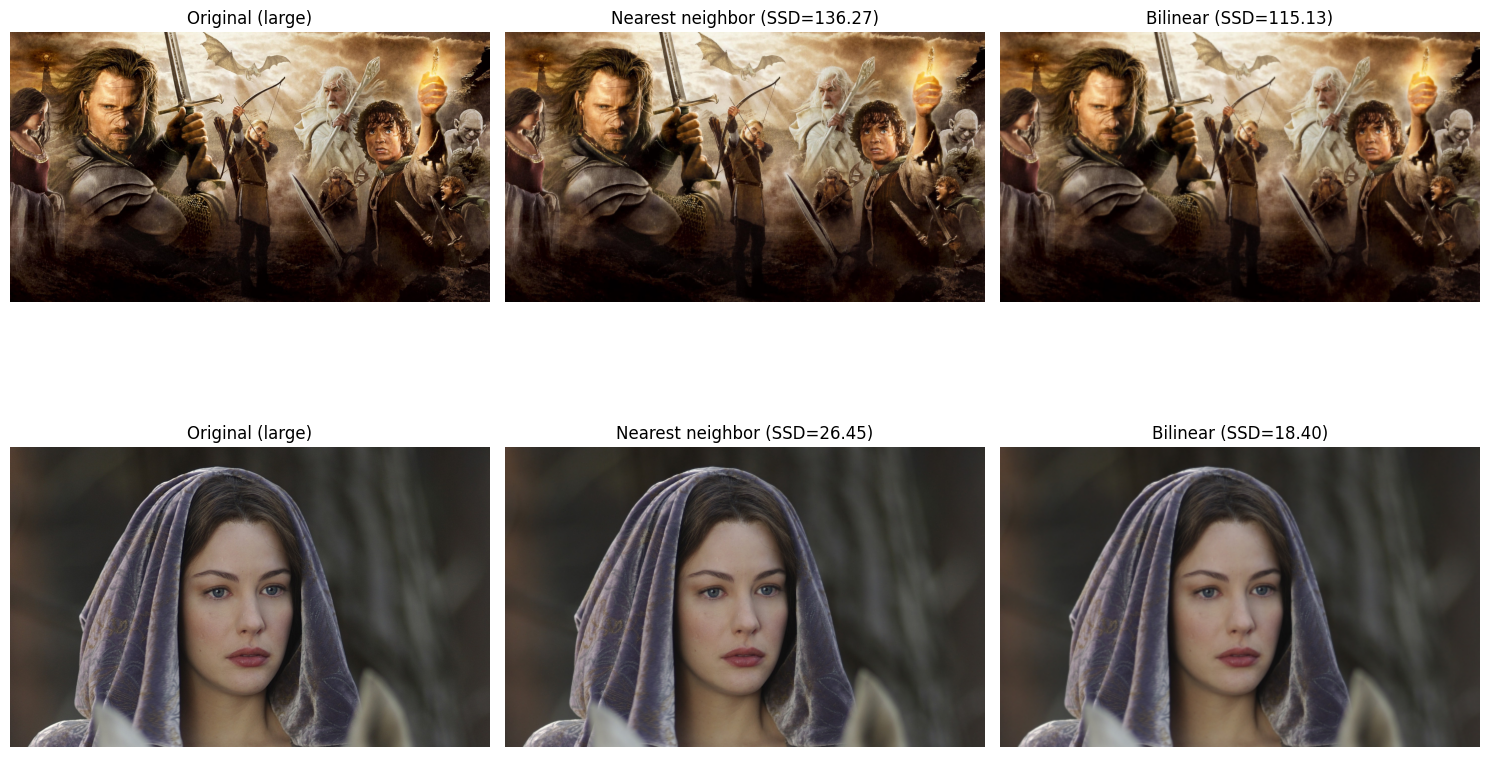

In [24]:
def normalized_ssd(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size

pairs = [
    ('images/zoom_small1.png', 'images/zoom_large1.png'),
    ('images/zoom_small2.png', 'images/zoom_large2.png'),
]

fig, axes = plt.subplots(len(pairs), 3, figsize=(15, 5 * len(pairs)))

for row, (small_path, large_path) in enumerate(pairs):
    small = cv2.imread(small_path)
    large = cv2.imread(large_path)

    zoomed_nn = zoom_image(small, 4, method='nearest')
    zoomed_bl = zoom_image(small, 4, method='bilinear')

    ssd_nn = normalized_ssd(zoomed_nn, large)
    ssd_bl = normalized_ssd(zoomed_bl, large)

    axes[row, 0].imshow(cv2.cvtColor(large, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title('Original (large)')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cv2.cvtColor(zoomed_nn, cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f'Nearest neighbor (SSD={ssd_nn:.2f})')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(cv2.cvtColor(zoomed_bl, cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title(f'Bilinear (SSD={ssd_bl:.2f})')
    axes[row, 2].axis('off')

    print(f'Image {row + 1}: nearest-neighbor SSD = {ssd_nn:.2f}, bilinear SSD = {ssd_bl:.2f}')

plt.tight_layout()
plt.show()


Bilinear interpolation gives a consistently lower normalized SSD than nearest-neighbor for both test images, since it blends the four nearest pixels instead of picking just one, avoiding the blocky artifacts nearest-neighbor produces.

## Question 9

### (a) Segmenting with grabCut

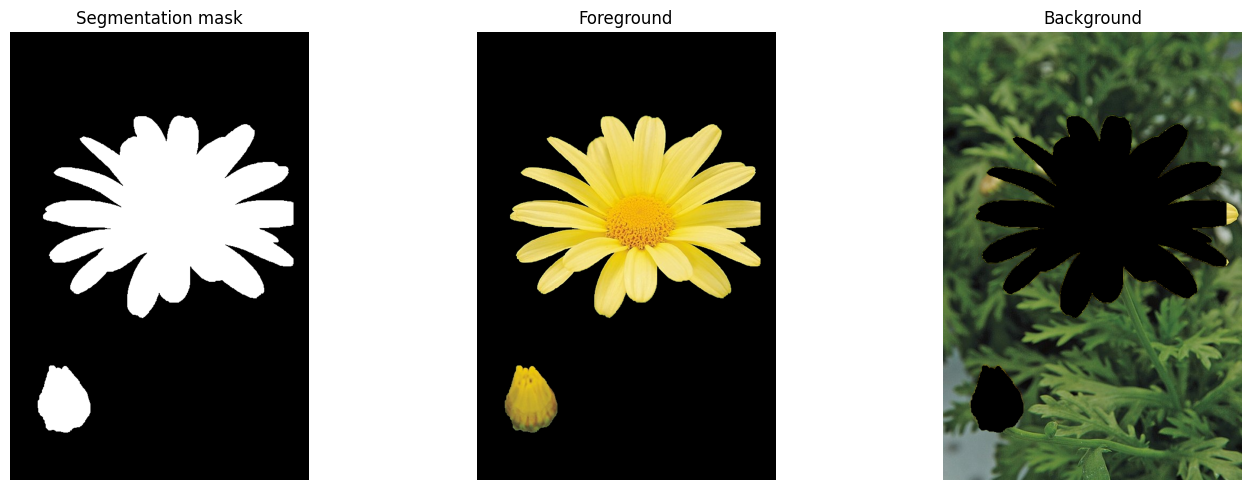

In [25]:
img9 = cv2.imread('images/flower_segmentation.jpeg')
h9, w9 = img9.shape[:2]

mask = np.zeros((h9, w9), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# A rectangle covering most of the frame, leaving a small margin
rect = (int(w9 * 0.05), int(h9 * 0.03), int(w9 * 0.9), int(h9 * 0.95))
cv2.grabCut(img9, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

# Pixels marked "definite/probable background" -> 0, else -> 1
fg_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

foreground = img9 * fg_mask[:, :, None]
background = img9 * (1 - fg_mask[:, :, None])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(fg_mask, cmap='gray')
axes[0].set_title('Segmentation mask')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
axes[1].set_title('Foreground')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
axes[2].set_title('Background')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) Blurring the background

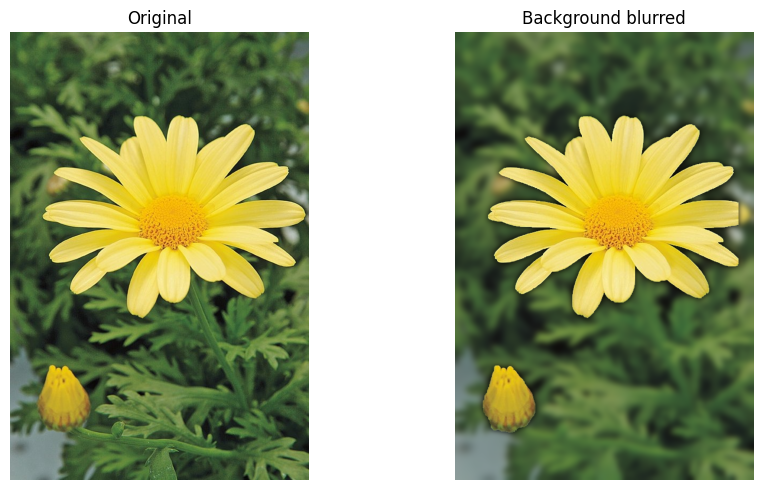

In [26]:
blurred_background = cv2.GaussianBlur(background, (35, 35), 0)
enhanced = foreground + blurred_background * (1 - fg_mask[:, :, None])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img9, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
axes[1].set_title('Background blurred')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### (c) Why is the background just beyond the edge of the flower dark?

The background image used for blurring has the foreground pixels zeroed out (set to black) before the Gaussian blur is applied. Near the flower's edge, the blur kernel averages in some of those black zeroed-out pixels from just inside the mask boundary, pulling the blurred background values down close to the edge. This creates a dark halo/ring immediately surrounding the flower in the enhanced image, even though the true background there was never that dark. It could be avoided by blurring the original image (not the zeroed-out background) and only using the mask to select which blurred pixels to keep.

## Question 10

### (a) OpenCV's bilateralFilter vs Gaussian blur

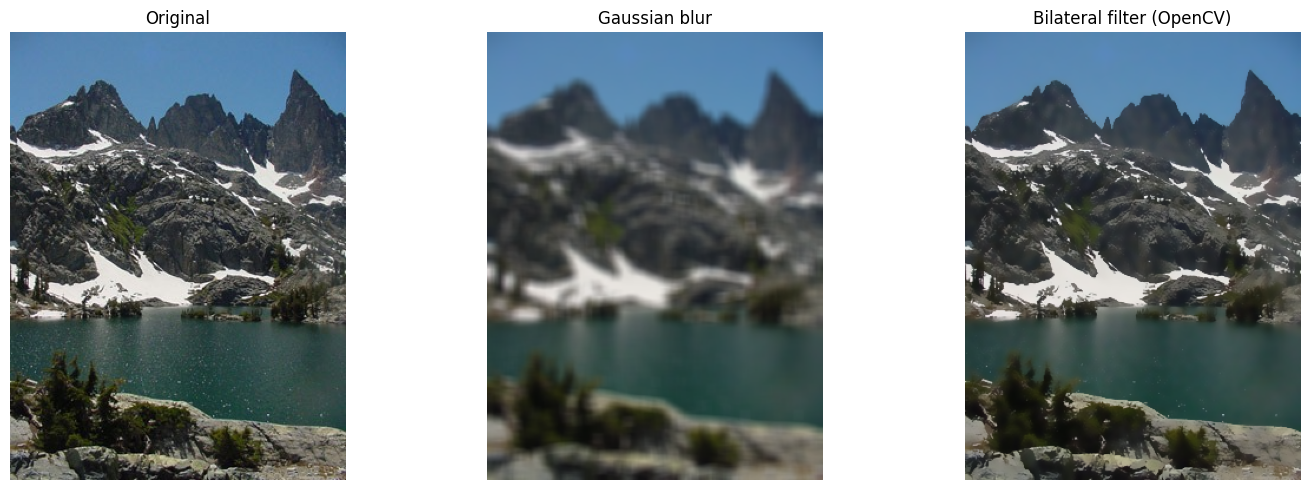

In [27]:
img10 = cv2.imread('images/lake_minaret.jpeg')

d = 9
sigma_s = 75
sigma_r = 75

gauss10 = cv2.GaussianBlur(img10, (d, d), sigma_s)
bilateral_cv = cv2.bilateralFilter(img10, d, sigma_r, sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img10, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(gauss10, cv2.COLOR_BGR2RGB))
axes[1].set_title('Gaussian blur')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(bilateral_cv, cv2.COLOR_BGR2RGB))
axes[2].set_title('Bilateral filter (OpenCV)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### (b) My bilateral filter

MSE vs OpenCV: 29.093844259772236


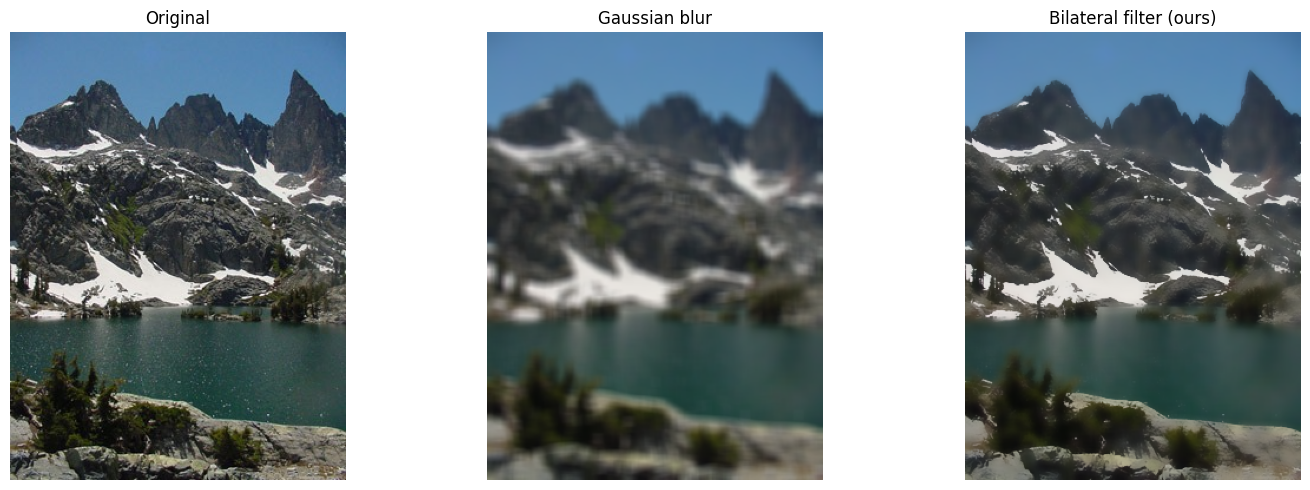

In [ ]:
def bilateral_filter(img, d, sigma_s, sigma_r):
    img = img.astype(np.float64)
    r = d // 2
    padded = np.pad(img, ((r, r), (r, r), (0, 0)), mode='reflect')
    out = np.zeros_like(img)
    wsum = np.zeros(img.shape[:2])

    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            shifted = padded[r + dy:r + dy + img.shape[0], r + dx:r + dx + img.shape[1]]
            spatial = np.exp(-(dy ** 2 + dx ** 2) / (2 * sigma_s ** 2))
            diff = shifted - img
            rang = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_r ** 2))
            w = spatial * rang
            out += shifted * w[:, :, None]
            wsum += w

    out /= wsum[:, :, None]
    return np.clip(out, 0, 255).astype(np.uint8)

bilateral_own = bilateral_filter(img10, d, sigma_s, sigma_r)

mse = np.mean((bilateral_own.astype(np.float64) - bilateral_cv.astype(np.float64)) ** 2)
print('MSE vs OpenCV:', mse)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img10, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(gauss10, cv2.COLOR_BGR2RGB))
axes[1].set_title('Gaussian blur')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(bilateral_own, cv2.COLOR_BGR2RGB))
axes[2].set_title('My Bilateral filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()
